In [27]:
import requests
from IPython.core.display import HTML
#HTML(f"""
#<style>
#@import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
#</style>
#""")

### Q3 Exercise Week 5 (Projections and Least Squares)

#### (a) Focus on the relation between linear least squares (function minimization) and projections.
- projections
- linear least squares as projection
- geometric interpretation

#### (b) Focus on linear least squares problems for model fitting (design matrix, kernel, lines, polynomials, affine, and other multivariate functions) and the interpretation of results for various types of models (see week 7).
- process of model fitting
    - types of linear models (via design matrix / kernel)
        - lines
        - polynomials
        - affine functions
        - multivariate functions (e.g., x and y coordinates) (W05 02)
- Interpretation of results for various types of models 
    - regression metrics ((R)MSE) (W07 02)
    - classification metrics (accuracy, precision, recall, F1-score) (W11 01)

#### (c) Learning of Affine (multivariate) functions and linear optimization.
- process of learning affine functions
    - design matrix for affine, multivariate functions (W05 02)
    - compute weights using least squares normal equation: $w = (A^T A)^{-1} A^T b$


# Experimenting with the tutorial

**Overview**
This exercise is related to the week 4 tutorial.
 
The individual tasks will ask you to either reflect on parts of the tutorial or modify specific code cells from the tutorial. Specifically, [Task 2](#project) and [Task 3](#ls) require modifications to the code of the tutorial notebook.
 


<article class="message">
    <div class="message-body">
        <strong>List of tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#copy">Task 1: Copy notebook</a>
            </li>
            <li>
            <a href="#project">Task 2: Projection experiments</a>
            </li>
            <li>
            <a href="#ls">Task 3: Linear Least Squares Experiments</a>
            </li>
            <li>
            <a href="#ls1">Task 4: Linear Least Squares Reflections</a>
            </li>
            <li>
            <a href="#poly">Task 5: Second-order polynomial</a>
            </li>
            <li>
            <a href="#pmatrix">Task 6: Projection matrix</a>
            </li>
        </ul>
    </div>
</article>


---
**Task 1 (easy): Copy notebook**
Copy the tutorial notebook
 in the repository. 
This makes it easy to go back to the original in case something goes wrong.

---
---
**Task 2 (easy): Projection experiments👩‍💻📽️**
This task builds on the $\textbf{Projections}$ section in the tutorial.
1. Search and identify comment `##1`
. 
2. Change the values of the matrix $A$ (below comment `##1`
) to modify the line. Experiment with different values and observe how the projection changes in the plot.
3. Change the matrix $A$, such that $PX$ ≈ $X$ (that is the projection leaves $X$ almost unchanged). 
4. Search and identify comment `##2`
.
5. Set the matrix $A$  = $\begin{bmatrix} 1 \\ 0.5 \end{bmatrix}$, then apply the projection matrix $P$ twice, i.e. calculate $PPX$ (just below the comment). How does this affect the projected points?


---

In [1]:
# Task 1
# OBS: I assume it is the notebook called "00-projection_least_sq.ipynb" I was supposed to copy. 
# Therefore, see "00-projection_least_sq copy.ipynb".

In [28]:
# Write your solution here
# Task 2.2
    # When I changed one of the values in the matrix A, the projection of b onto the line defined by A also changed.
    # I observed how changing A from [[1], [0.5]] to [[1], [1]] moved all the projected points to a line with a slope of 1.
    # When I instead changed A to [[2], [0.5]], the projected points moved to a line with a different slope, specifically a slope of 0.25.
    # I see how the first element of A: a_1, and the second element of A: a_2, influence the direction of the line defined by A.
    # The function of the line of the projection can be described as  y = (a_2/a_1)x.
    # When I changed A to [[2], [1]], the projected points was not affected compared to the original A.
    # This is because [[2], [1]] is just a scaled version of the original A, and scaling A does not change the direction of the line it defines, only its length.

# Task 2.3 Change the matrix A, such that PX ≈ X (the projections are approximately the same as the original points).
    # The original points A does not really form a line which can be bescribed such that PX = X exactly.
    # The original points are:
    # X = np.array([
    # [1, 2],
    # [2, 1.5],
    # [3, 1.2]
    # ]).T
    # By observing the points, I can see that they roughly follows a line with a negative slope (not exactly, but close).
    # But i can also see that that line does not go through 0.0 (i.e. y-intercept is not 0).
    # This means that I cannot find a matrix A such that PX = X exactly (and not very close), since the projection matrix P only projects onto lines that go through the origin. I would need to add an offset (y-intercept) to the projection in order to get a good fit.
    # The closest i can get will be a line that goes through the origin and has a positive slope going through somewhere in the middle of the points (values around (1.3, 1)). The best fitting line could be found using least squares regression.

# Task 2.5 Set the matrix A=[[1],[0.5]], then apply the projection matrix P twice, i.e. calculate PPX (just below the comment). How does this affect the projected points?
    # It does not affect the projected points. Applying the projection matrix P twice (PPX) yields the same result as applying it once (PX).
    # The effect of applying the projection matrix P is to project the points onto the line defined by A.
    # Once the points are projected onto that line, applying the projection again does not change their position, since they are already on the line (the projection on the line for a point which is already on the line will be itself).
    # Therefore, PPX = PX.


---
**Task 3 (easy): Linear Least Squares Experiments👩‍💻**
This task builds on the $\textbf{Linear Least Squares}$ section in the tutorial.
1. Search and identify comment `##3`
.
2. Change the values of the first point in the matrix `X`
 such that it gradually moves further and further away from the line. Observe how it affects the error $RMS$.
3. Add two points to `X`
 and observe how they affect the fitted line and the error.


---

In [29]:
# Write your solutions here
# Task 3.2
    # As I changed the values of the first point in the matrix X to be further away from the line,
    # I saw that the error RMS increased. This was also what I expected, since the distance from the point to the line increased.
    # The projection of the other points remained the same, since only one point was changed, but the overall fit of the line to the points got worse.
    # In the graph, I observed that when I changed the first point further away from the line, all the projected points and the line changed accordingly.
    # Specifically, the line adjusted its slope and position to minimize the overall distance to all points,
    # resulting in a new projection that better fits the modified set of points. But since the point was moved further away, the overall error still increased.

# Task 3.3
    # Before adding any new point, the weights where: 0.9 and -0.4.
    # I added the point [4, 3.2] (Since the weights calculated from the original three points was roughly y = 0.9x - 0.4, I chose the point [4, 3.2], since it lies on the line of the previous predictions).
    # The rms error changed from 0.7348469228349533 to 0.7348469228349536. (Not a significant change, but still a change).

    # Then I added the point [5, 10] (which is further away from the line of the previous predictions).
    # The rms error changed from 0.7348469228349536 to 3.8031565836815076. (A significant increase in error, as expected, since the new point is far from the line of best fit).



---
**Task 4 (easy): Linear Least Squares Reflections💡📽️**
1. How can you change the two additional points so the fitted line does not move?
2. What happens to the error when removing all but two points from `X`
?
3. What happens when you remove all but one point from `X`
?
4. Reflect on how the quality of the data affects the projection and thus the solution. 


---

In [30]:
# Write your reflections here
# Task 4.1
    # To avoid the fitted line moving when adding the new points, I could add two points that are symmetric around the current line of best fit.
    # For example, if the current line of best fit is y = mx + b,
    # I could add a point (x1, y1) above the line and another point (x2, y2) below the line such that:
    # y1 = mx1 + b + d
    # y2 = mx2 + b - d
    # where d is the same distance from the line for both points.
    # By adding these two points, their effects on the line of best fit would cancel each other out, keeping the line in the same position.
    # 
# Task 4.2 Removing all but two points will result in an rms error of zero.
    # If there is only two points, the line of best fit will always pass through both points exactly.
    # This means that the rms error will be zero, as there is no distance between the points and the line.
# Task 4.3 Removing all but one point will also result in an rms error of zero, but will not define a line.
    # With only one point, any line passing through that point will have zero distance to the point, resulting in an rms error of zero.
    # However, a single point does not provide enough information to define a unique line, as there are infinitely many lines that can pass through a single point.
# Task 4.4 How the quality of the data affects the projection and thus the solution
    # If the data points are very close to a straight line, the projection will be more accurate, resulting in a lower rms error.
    # Conversely, if the data points are widely scattered, the projection will be less accurate, leading to a higher rms error.
    # Outliers can significantly affect the projection, as they can skew the line of best fit away from the majority of the data points, increasing the rms error.
    # If an outlier is caused by bad-quality data (e.g., measurement error), it can mislead the projection and result in a poor fit overall, even if the other data points are of high quality.
    # In short, bad quality data makes bad predictions.


## Pen and paper exercises
A 2. order polynomial is given by 

$$f(x) = w_0 + w_1x + w_2x^2 = \sum^2_{i=0} w_ix^i.$$

Generally, an $N$'th order  polynomial is given by

$$f(x) = \sum^N_{i=0} w_ix^i,$$
where $\mathbb{w}$ is a vector of coefficients.

---
**Task 5 (medium): Second-order polynomial♾️📽️**
1. Identify the knowns and unknowns in the polynomial above.
2. Is the function linear or non-linear in $\mathbb{w}$?
3. Is the function linear or non-linear in $\mathbb{x}$?
4. Provide the outline of an algorithm for fitting a second-order polynomial using linear least squares.
5. Generalize this algorithm to n-th order polynomials.


---

A
 [[  1.   1.   1.   1.]
 [  1.   2.   4.   8.]
 [  1.   3.   9.  27.]
 [  1.   4.  16.  64.]
 [  1.   5.  25. 125.]]
P:
 [[ 3.20000000e+00 -2.80000000e+00 -8.00000000e-01  2.20000000e+00
  -8.00000000e-01]
 [-3.02380952e+00  4.26190476e+00  8.57142857e-01 -3.40476190e+00
   1.30952381e+00]
 [ 8.92857143e-01 -1.57142857e+00 -1.42857143e-01  1.42857143e+00
  -6.07142857e-01]
 [-8.33333333e-02  1.66666667e-01  8.49320614e-15 -1.66666667e-01
   8.33333333e-02]]
w: [-7.52       11.83333333 -4.75        0.61666667]


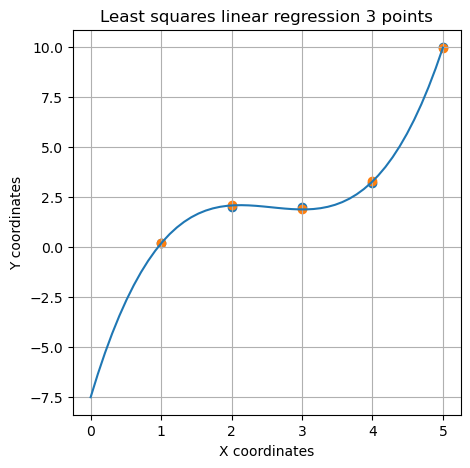

In [ ]:
# Write your solution here
# Task 5.1
    # Knowns: I assume we have some data consisting of the input data points X and their corresponding output values f(x).
    # Unknowns: the weights w that define the linear relationship between X and f(x).
# Task 5.2
    # linear/non-linear in w?: It is linear in w, since the function can be expressed as a linear combination of the weights w.
# Task 5.3    
    # linear/nonlinear in x?: It is not linear in x, since the function include a polynomial term of x (x^2), and a constant term, making it a nonlinear function of x.
# Task 5.4
    # The outline of an algorithm for fitting a second-order polynomial using linear least squares could be as follows:
        # First, create the design matrix A, where each row corresponds to a data point and contains the terms [1, x, x^2] for each input value x.
        # Then, calculate the weights w using the formula w = (A^T A)^(-1) A^T y, where y is the vector of output values f(x).
        #    The resulting weights w will define the fitted second-order polynomial of the form f(x) = w_0 + w_1*x + w_2*x^2.
# Task 5.5
    # Generalization to n-th order polynomials:
        # (See code below)
        # First, create the design matrix A, where each row corresponds to a data point and contains the terms [1, x, x^2, ..., x^n] for each input value x.
        # Then, calculate the weights w using the formula w = (A^T A)^(-1) A^T y, where y is the vector of output values f(x).
        #  The resulting weights w will define the fitted n-th order polynomial of the form f(x) = w_0 + w_1*x + w_2*x^2 + ... + w_n*x^n.
import numpy as np
import matplotlib.pyplot as plt

def predict_nth_order_polynomial(X, n):
    x_vals = X[0, :]
    y_vals = X[1, :]

    # Creating the design matrix A for n-th order polynomial
    A = np.vstack([x_vals ** i for i in range(n+1)]).T
    print("A\n", A)

    P = np.linalg.inv(A.T @ A) @ A.T
    print("P:\n", P)
    # Applying the transformation
    w = P @ y_vals
    print("w:", w)

    # Calculating the projected y-values
    y_hat = A @ w

    x = np.linspace(0, 5)  # Create range of values
    y = 0
    for i in range(n+1):
        y += w[i] * (x ** i) # Calculate f(x)

    plt.figure(figsize=(5, 5))

    plt.plot(x, y)  # Plot line
    plt.scatter(X[0, :], X[1, :])  # Plot original points

    plt.scatter(X[0, :], y_hat)  # Plot the points
    plt.title('Least squares linear regression 3 points')
    plt.xlabel("X coordinates")
    plt.ylabel("Y coordinates")
    plt.grid(True)
    plt.show()

# Example usage:
X = np.array([
    [1, 0.2],
    [2, 2],
    [3, 2],
    [4, 3.2],
    [5, 10]
]).T

n = 3  # Degree of the polynomial
predict_nth_order_polynomial(X, n)


---
**Task 6 (medium): Projection matrix♾️**
The projection matrix $P = A(A^\top A )^{-1}A^\top$ is, under certain conditions, equal to the identity matrix.
1. Give an example of a design matrix $A$ for which $P=I$.
2. Explain why projection matrices are usually not identity matrices.
3. (optional) Prove a condition for which $P=I$. Hint: when is $A^\top A=I$?.


---

In [ ]:
# Write your solution here
# Task 6.1 Give an example of a design matrix A for which P=I
    # One example of a design matrix A for which the projection matrix P equals the identity matrix I is when A is an orthonormal basis.
    # For instance, if we have a 2D space, we can use the standard basis vectors as our design matrix:
    # A = np.array([[1, 0], [0, 1]])
    # In this case, the projection matrix P will be equal to the identity matrix I, since projecting any vector onto the space spanned by these basis vectors will yield the same vector.
    # Mathematically:
        # P = A(A^T A)^(-1) A^T
        # If A is an orthonormal basis, then A^T A = I (the identity matrix).
        # Therefore, (A^T A)^(-1) = I as well.
        # Substituting this back into the expression for P gives:
        # P = A(A^T A)^(-1) A^T = A * I * A^T = A * A^T
        # Since A is an orthonormal basis, A * A^T = I.
        # Thus, P = I.

# Task 6.2 Explain why projection matrices are usually not identity matrices.
    # Projection matrices are usually not identity matrices because they are designed to project vectors onto a specific subspace rather than leaving them unchanged.
    # The identity matrix represents a transformation that does not alter any vector it is applied to, meaning every vector remains the same after the transformation.
    # In contrast, a projection matrix maps vectors onto a lower-dimensional subspace, which typically results in a loss of information.
    # For example, when projecting points onto a line or a plane, the projection matrix will alter the original vectors to fit within that subspace, changing their direction and magnitude.
    # Therefore, unless the subspace onto which we are projecting is the entire space itself (which would make the projection matrix the identity matrix), projection matrices will generally not be identity matrices.

# Task 6.3 Prove a condition for which P = I. (Hint: when is A^T A = I?)
    #(Also answered in task 6.1)
    # The condition for which the projection matrix P equals the identity matrix I is when the design matrix A has orthonormal columns.
    # This means that the columns of A are orthogonal to each other and each column has a unit length.
    # Mathematically, this condition can be expressed as:
        # A^T A = I
    # where I is the identity matrix.
    # When A has orthonormal columns, the inner product of any two different columns is zero (orthogonality), and the inner product of each column with itself is one (unit length).
    # Under this condition, the projection matrix P can be derived as follows:
        # P = A(A^T A)^(-1) A^T
        # Since A^T A = I, we have (A^T A)^(-1) = I as well.
        # Substituting this back into the expression for P gives:
        # P = A * I * A^T = A * A^T
        # Since A has orthonormal columns, A * A^T = I.
        # Thus, P = I.